### Построение представлений из многоканальных временных рядов ЭЭГ. Классификация умственной нагрузки


In [ ]:
from eeg_learn_functions import *

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scs
import re
from numpy import genfromtxt

%matplotlib inline
plt.style.use('ggplot')
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams["figure.figsize"] = (12,12)
pd.options.display.max_columns = None
pd.options.display.precision = 4

#### Частоты мозговых волн:
Gamma, 30 to 50 Hz.  
Beta, 14 to 30 Hz.  
Alpha, 8 to 14 Hz.  
Theta, 4 to 8 Hz.  
Delta, 0.1 to 4 Hz.  

Библиотека для анализа EEG сигналов:  
https://github.com/pbashivan/EEGLearn

In [ ]:
theta = (4,8)
alpha = (8,12)
beta = (12,40)

In [ ]:
def get_fft(snippet):
    Fs = 128.0;  # частота сэмплирования
    snippet_time = len(snippet)/Fs
    Ts = 1.0/Fs; # интервал
    t = np.arange(0,snippet_time,Ts) # вектор времени
    y = snippet
    n = len(y) 
    k = np.arange(n)
    T = n/Fs
    frq = k/T 
    frq = frq[range(n//2)] 

    Y = np.fft.fft(y)/n 
    Y = Y[range(n//2)]
    return frq,abs(Y)

In [ ]:
def theta_alpha_beta_averages(f,Y):
    theta_range = (4,8)
    alpha_range = (8,12)
    beta_range = (12,40)
    theta = Y[(f>theta_range[0]) & (f<=theta_range[1])].mean()
    alpha = Y[(f>alpha_range[0]) & (f<=alpha_range[1])].mean()
    beta = Y[(f>beta_range[0]) & (f<=beta_range[1])].mean()
    return theta, alpha, beta

In [ ]:
def make_steps(samples,frame_duration,overlap):
    '''
    in:
    samples - количество сэмплов в одной сессии
    frame_duration - длительность фрейма в секундах 
    overlap - часть накладываемого фрейма в диапазоне (0,1)
    
    out: list of tuple ranges
    '''
    Fs = 128
    i = 0
    intervals = []
    samples_per_frame = Fs * frame_duration
    while i+samples_per_frame <= samples:
        intervals.append((i,i+samples_per_frame))
        i = i + samples_per_frame - int(samples_per_frame*overlap)
    return intervals

In [ ]:
def make_frames(df,frame_duration):
    '''
    in: датафрейм или массив со всеми каналами, длительностью фрейма в секундах
    out: массив средних значений theta, alpha, beta для каждой пробы в каждый момоент времени
        размерность: (n-frames,m-probes,k-brainwave bands)
    '''
    Fs = 128.0
    frame_length = Fs*frame_duration
    frames = []
    steps = make_steps(len(df),frame_duration,overlap)
    for i,_ in enumerate(steps):
        frame = []
        if i == 0:
            continue
        else:
            for channel in df.columns:
                snippet = np.array(df.loc[steps[i][0]:steps[i][1],int(channel)])
                f,Y =  get_fft(snippet)
                theta, alpha, beta = theta_alpha_beta_averages(f,Y)
                frame.append([theta, alpha, beta])
            
        frames.append(frame)
    return np.array(frames)

In [ ]:
locs_2d = [(-2.0,4.0),
           (2.0,4.0),
           (-1.0,3.0),
           (1.0,3.0),
           (-3.0,3.0),
           (3.0,3.0),
           (-2.0,2.0),
           (2.0,2.0),
           (-2.0,-2.0),
           (2.0,-2.0),
           (-4.0,1.0),
           (4.0,1.0),
           (-1.0,-3.0),
           (1.0,-3.0)]

In [ ]:
def make_data_pipeline(file_names,labels,image_size,frame_duration,overlap):
    '''
    IN: 
    file_names - список строк для каждого входного файла (один на каждого индивида)
    labels - лист меток
    image_size - размер выходного изображения в формате (x, x)
    frame_duration - длительность каждого фрейма (секунды)
    overlap - часть накладываемого фрейма в диапазоне (0,1)
    
    OUT:
    X: np array фреймов (unshuffled)
    y: np array меток для каждого фрейма (1 или 0)
    '''
    
    Fs = 128.0   #частота сэмлирования
    frame_length = Fs * frame_duration
    
    print('Генерирование обучающей выборки ...')
    
    
    for i, file in enumerate(file_names):
        print ('Сессия обработки: ',file, '. (',i+1,' of ',len(file_names),')')
        data = genfromtxt(file, delimiter=',').T
        df = pd.DataFrame(data)
        
        X_0 = make_frames(df,frame_duration)
        X_1 = X_0.reshape(len(X_0),14*3)
        
        images = gen_images(np.array(locs_2d),X_1, image_size, normalize=False)
        images = np.swapaxes(images, 1, 3) 
        print(len(images), ' фреймов, сгенерированных с меткой ', labels[i], '.')
        print('\n')
        if i == 0:
            X = images
            y = np.ones(len(images))*labels[0]
        else:
            X = np.concatenate((X,images),axis = 0)
            y = np.concatenate((y,np.ones(len(images))*labels[i]),axis = 0)
        
    return X,np.array(y)

In [ ]:
from numpy import genfromtxt
data = genfromtxt('data/ML101_KS.csv', delimiter=',').T
df = pd.DataFrame(data)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-78.03,-75.99,-88.74,-87.21,-53.04,-64.77,-69.87,-80.07,-72.42,-68.85,-77.01,-69.87,-102.00,-116.79
1,-79.56,-77.01,-92.82,-93.84,-54.57,-65.79,-82.62,-93.33,-71.91,-78.03,-76.50,-59.67,-97.41,-121.38
2,-77.52,-77.01,-92.31,-89.76,-78.54,-59.16,-76.50,-75.99,-84.66,-61.71,-80.58,-71.91,-102.00,-139.23
3,-78.54,-73.44,-87.21,-81.60,-67.83,-59.16,-74.46,-67.83,-85.17,-55.08,-83.64,-83.13,-99.96,-136.17
4,-74.46,-64.26,-81.09,-75.48,-57.63,-62.73,-75.48,-75.48,-73.44,-62.73,-84.15,-79.56,-92.31,-128.52


In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000
mean,-74.5237,-74.5262,-75.2090,-84.5480,-74.6888,-74.4620,-74.7108,-75.0444,-74.7568,-73.7301,-74.6366,-73.9806,-74.8771,-74.5024
std,22.7225,18.4686,16.2207,18.7864,21.9575,20.9349,16.1172,19.7323,11.7411,21.0242,11.2846,16.8376,13.4574,20.6445
min,-184.6200,-170.3400,-170.8500,-200.4300,-167.2800,-175.9500,-148.9200,-156.5700,-132.6000,-163.2000,-119.8500,-150.9600,-135.6600,-174.4200
25%,-89.2500,-86.1900,-85.6800,-95.8800,-89.2500,-88.2300,-85.1700,-88.2300,-81.6000,-87.7200,-81.0900,-83.6400,-82.6200,-88.2300
50%,-75.9900,-75.4800,-75.9900,-84.1500,-74.4600,-74.9700,-74.9700,-75.4800,-74.9700,-74.4600,-75.4800,-74.9700,-75.4800,-74.4600
75%,-61.2000,-62.2200,-63.7500,-73.9500,-60.1800,-60.6900,-63.7500,-61.7100,-66.3000,-59.6700,-65.2800,-62.2200,-64.7700,-60.6900
max,39.7800,10.7100,10.2000,10.7100,16.8300,51.5100,-8.6700,19.3800,-34.1700,20.4000,-25.5000,7.6500,-2.0400,11.2200


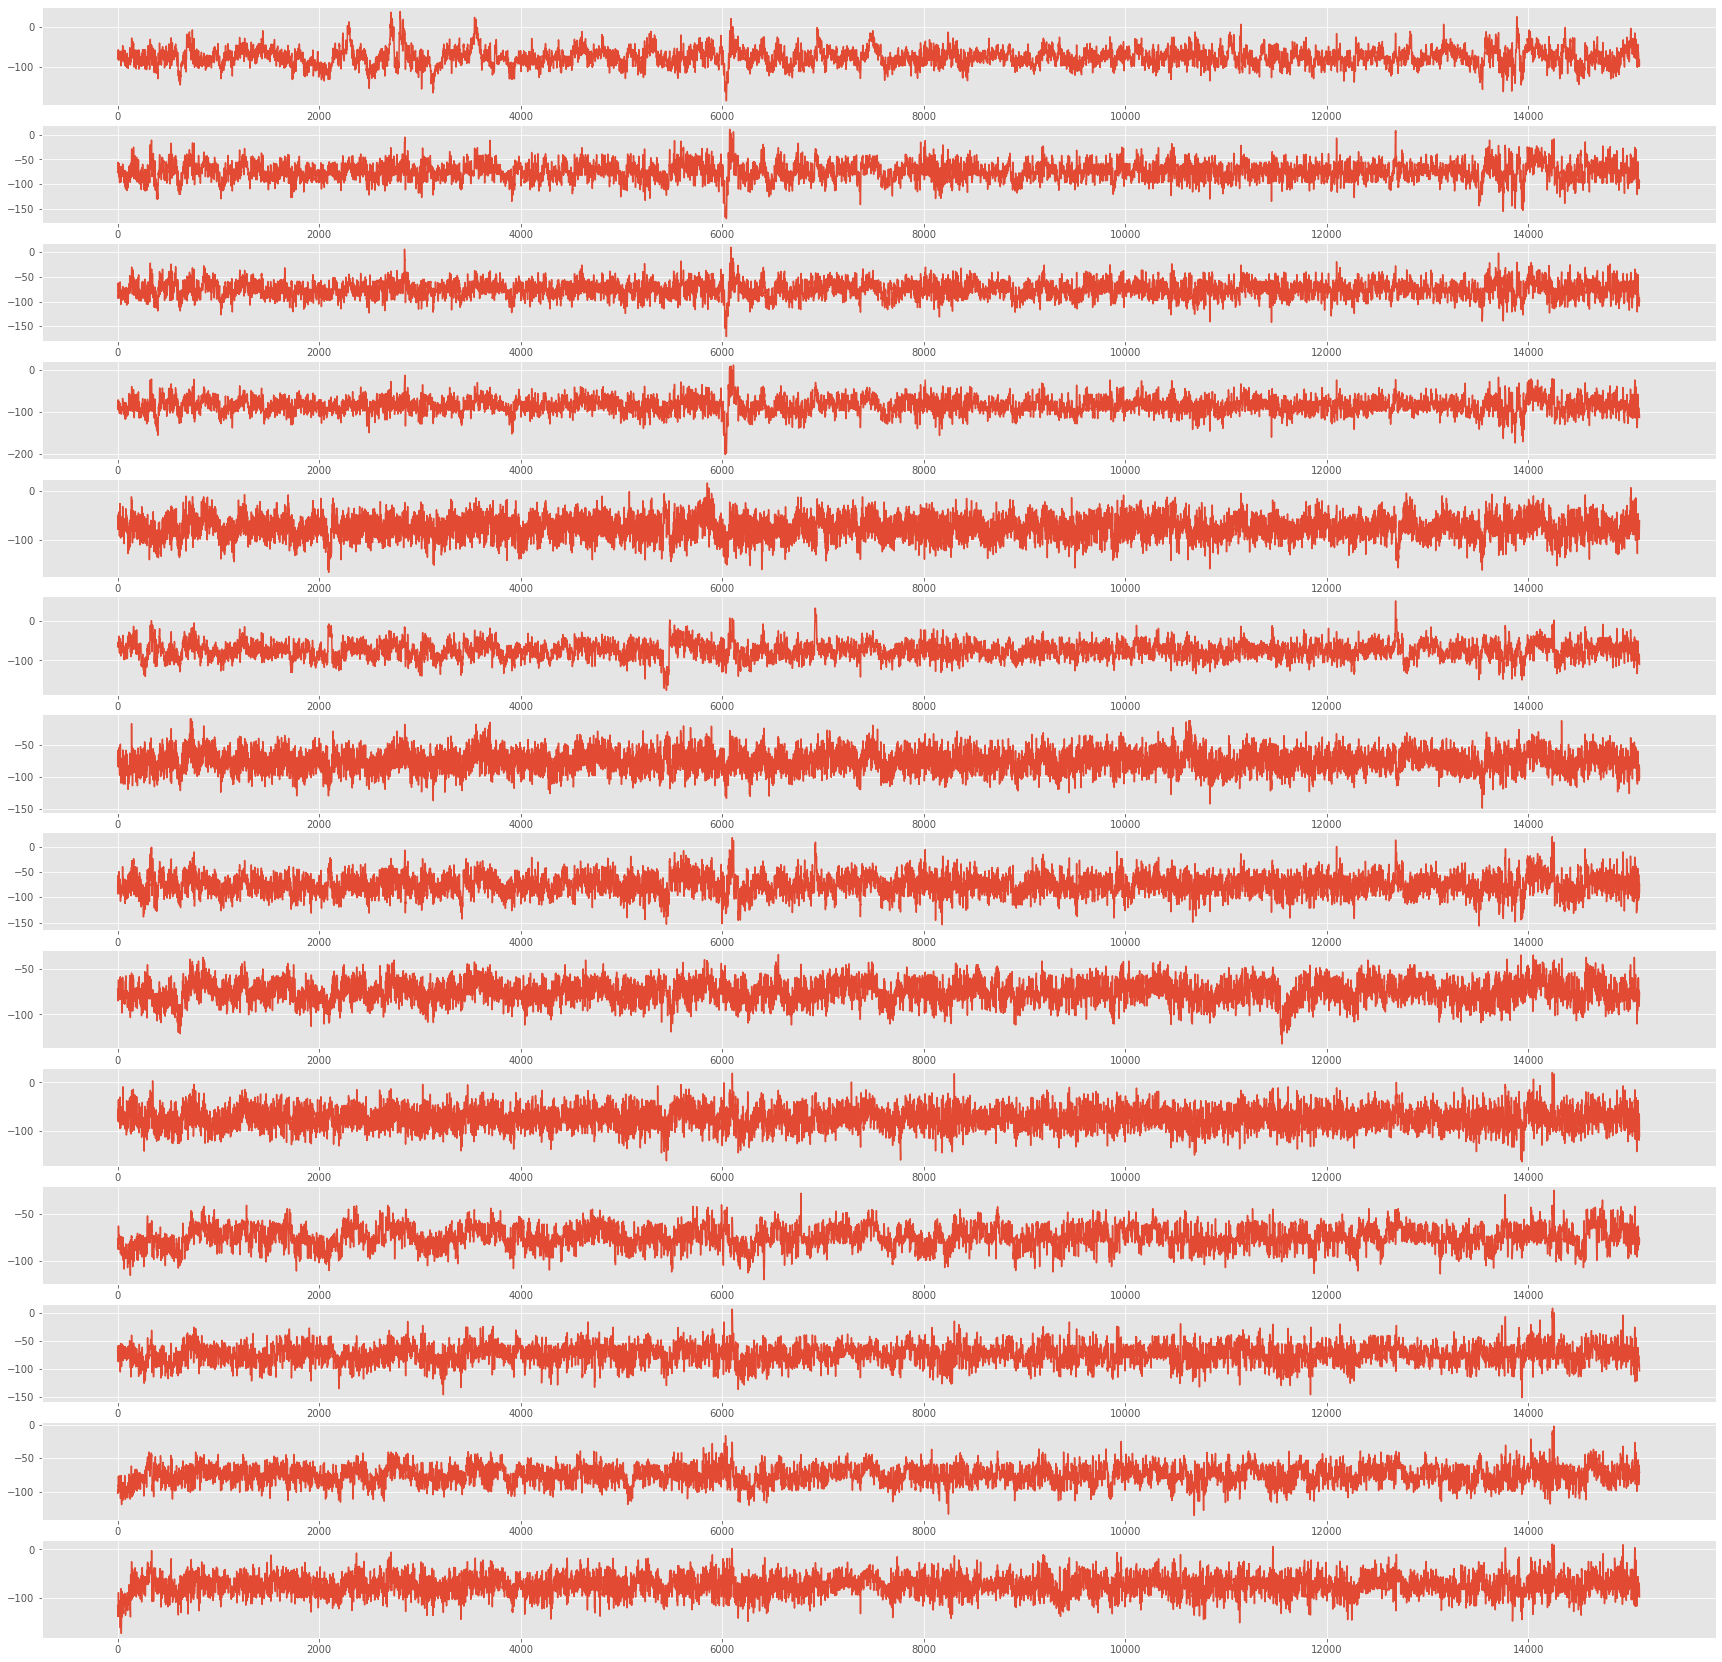

In [ ]:
fig, axs = plt.subplots(14, 1, figsize=(30,30))
for i, ax in enumerate(fig.axes):
    ax.plot(df.iloc[:,i])
    #ax.set_xticks([])
    #ax.set_yticks([])
plt.show()

In [ ]:
file_names = ['data/ML101_KS.csv',
              'data/ML101_US.csv',
              'data/ML102_KS.csv',
              'data/ML102_US.csv',
              'data/ML103_KS.csv',
              'data/ML103_US.csv',
              'data/ML104_KS.csv',
              'data/ML104_US.csv',
              'data/ML105_KS.csv',
              'data/ML105_US.csv',
              'data/ML106_KS.csv',
              'data/ML106_US.csv',
              'data/ML107_KS.csv',
              'data/ML107_US.csv',
              'data/ML108_KS.csv',
              'data/ML108_US.csv']
labels = [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]
image_size = 28
frame_duration = 1.0
overlap = 0.5
X, y = make_data_pipeline(file_names,labels,image_size,frame_duration,overlap)

Генерирование обучающей выборки ...
Сессия обработки:  data/ML101_KS.csv . ( 1  of  16 )
234  фреймов, сгенерированных с меткой  1 .


Сессия обработки:  data/ML101_US.csv . ( 2  of  16 )
224  фреймов, сгенерированных с меткой  0 .


Сессия обработки:  data/ML102_KS.csv . ( 3  of  16 )
222  фреймов, сгенерированных с меткой  1 .


Сессия обработки:  data/ML102_US.csv . ( 4  of  16 )
218  фреймов, сгенерированных с меткой  0 .


Сессия обработки:  data/ML103_KS.csv . ( 5  of  16 )
226  фреймов, сгенерированных с меткой  1 .


Сессия обработки:  data/ML103_US.csv . ( 6  of  16 )
208  фреймов, сгенерированных с меткой  0 .


Сессия обработки:  data/ML104_KS.csv . ( 7  of  16 )
202  фреймов, сгенерированных с меткой  1 .


Сессия обработки:  data/ML104_US.csv . ( 8  of  16 )
204  фреймов, сгенерированных с меткой  0 .


Сессия обработки:  data/ML105_KS.csv . ( 9  of  16 )
214  фреймов, сгенерированных с меткой  1 .


Сессия обработки:  data/ML105_US.csv . ( 10  of  16 )
226  фреймов, сгене

In [ ]:
X.shape

(3642, 28, 28, 3)

In [ ]:
y.shape

(3642,)

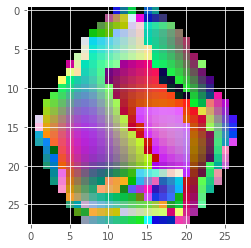

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow((X[0] * 255).astype(np.uint8));

''

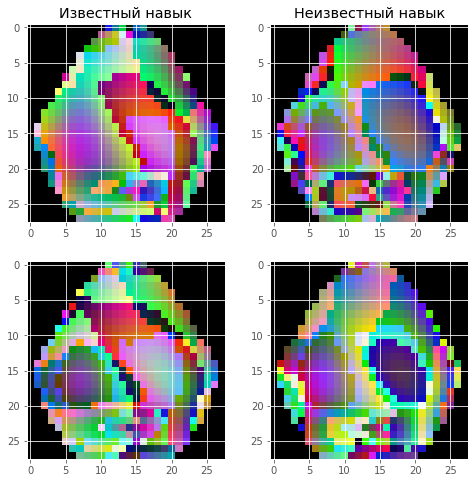

In [ ]:
f, axarr = plt.subplots(2,2, figsize = (8,8))
axarr[0][0].set_title('Известный навык')
axarr[0][0].imshow((X[0]* 255).astype(np.uint8))
axarr[1][0].imshow((X[1]* 255).astype(np.uint8))

axarr[0][1].set_title('Неизвестный навык')
axarr[0][1].imshow((X[20]* 255).astype(np.uint8))
axarr[1][1].imshow((X[21]* 255).astype(np.uint8))

;

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20,shuffle=True)

In [ ]:
y_train.shape

(2913,)

In [ ]:
# input image dimensions
img_rows, img_cols = 28, 28

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
#x_train /= 255
#x_test /= 255
print('x_train размер:', x_train.shape)
print(x_train.shape[0], 'обучающих примеров')
print(x_test.shape[0], 'контрольных примеров')

input_shape = (img_rows, img_cols, 3)

x_train размер: (2913, 28, 28, 3)
2913 обучающих примеров
729 контрольных примеров


In [ ]:
num_classes

2

In [ ]:
x_test.shape

(729, 28, 28, 3)

#### Построение модели сверточной нейронной сети

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D

batch_size = 128
num_classes = 2
epochs = 400

# преобразование вектора меток в бинарные матрицы
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same',input_shape=input_shape))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(10))
model.add(Activation('relu'))
#model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation('softmax'))

# инициализация алгоритма оптимизации
opt = keras.optimizers.RMSprop(lr=0.0001, decay=1e-6)

# обучение модели 
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
#x_train /= 255
#x_test /= 255


model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(x_test, y_test),
          shuffle=True)

[1. 1. 1. ... 0. 1. 0.]
[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [0. 1.]
 [1. 0.]]
Epoch 1/400
23/23 [==============================] - 4s 172ms/step - loss: 0.7254 - accuracy: 0.5221 - val_loss: 0.8268 - val_accuracy: 0.4979
Epoch 2/400
23/23 [==============================] - 4s 164ms/step - loss: 0.7037 - accuracy: 0.5396 - val_loss: 0.6853 - val_accuracy: 0.5295
Epoch 3/400
23/23 [==============================] - 4s 164ms/step - loss: 0.6904 - accuracy: 0.5379 - val_loss: 0.7215 - val_accuracy: 0.5117
Epoch 4/400
23/23 [==============================] - 4s 164ms/step - loss: 0.6983 - accuracy: 0.5249 - val_loss: 0.6749 - val_accuracy: 0.5638
Epoch 5/400
23/23 [==============================] - 4s 164ms/step - loss: 0.6835 - accuracy: 0.5400 - val_loss: 0.6761 - val_accuracy: 0.5432
Epoch 6/400
23/23 [==============================] - 4s 164ms/step - loss: 0.6742 - accuracy: 0.5709 - val_loss: 0.6893 - val_accuracy: 0.5460
Epoch 7/400
23/23 [==============================] - 4s 16